# Tarea 3 - Minería de Datos Avanzada: Regresion lineal y PCA

**Estudiante:** Eriksson Hernandez  
**Dataset:** `meatspec.csv`  
**Tema:** Regresion lineal y PCA aplicados a un dataset de espectros de carne.

En este notebook se prepara el dataset `meatspec.csv`, se separa en conjuntos de entrenamiento y prueba, se normalizan las variables predictoras y se compara una regresion lineal sin PCA contra regresiones lineales con reduccion de variables mediante PCA.

## 1. Carga de librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

## 2. Parametros generales

In [ ]:
DATA_PATH = "../data/meatspec.csv"

# Primeros digitos del CUI utilizados como semilla de reproducibilidad.
RANDOM_STATE_CUI = 2927

TRAIN_SIZE = 0.70
THRESHOLDS = [0.50, 0.60, 0.70, 0.80, 0.90]

## 3. Carga y exploracion inicial de datos

In [3]:
datos = pd.read_csv(DATA_PATH, index_col=0)

print(f"Filas: {datos.shape[0]}")
print(f"Columnas: {datos.shape[1]}")
datos.head()

Filas: 215
Columnas: 101


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V92,V93,V94,V95,V96,V97,V98,V99,V100,fat
1,2.61776,2.61814,2.61859,2.61912,2.61981,2.62071,2.62186,2.62334,2.62511,2.62722,...,2.98145,2.96072,2.94013,2.91978,2.89966,2.87964,2.85960,2.83940,2.81920,22.5
2,2.83454,2.83871,2.84283,2.84705,2.85138,2.85587,2.86060,2.86566,2.87093,2.87661,...,3.29186,3.27921,3.26655,3.25369,3.24045,3.22659,3.21181,3.19600,3.17942,40.1
3,2.58284,2.58458,2.58629,2.58808,2.58996,2.59192,2.59401,2.59627,2.59873,2.60131,...,2.68951,2.67009,2.65112,2.63262,2.61461,2.59718,2.58034,2.56404,2.54816,8.4
4,2.82286,2.82460,2.82630,2.82814,2.83001,2.83192,2.83392,2.83606,2.83842,2.84097,...,2.97367,2.94951,2.92576,2.90251,2.87988,2.85794,2.83672,2.81617,2.79622,5.9
5,2.78813,2.78989,2.79167,2.79350,2.79538,2.79746,2.79984,2.80254,2.80553,2.80890,...,3.30025,3.27907,3.25831,3.23784,3.21765,3.19766,3.17770,3.15770,3.13753,25.5


In [4]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 1 to 215
Columns: 101 entries, V1 to fat
dtypes: float64(101)
memory usage: 169.8 KB


In [5]:
datos.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
V1,215.0,2.808561,0.410793,2.06642,2.512265,2.75360,3.006155,4.23728
V2,215.0,2.811137,0.413352,2.06583,2.513260,2.75518,3.010470,4.24721
V3,215.0,2.813727,0.415906,2.06518,2.514210,2.75668,3.014840,4.25737
V4,215.0,2.816363,0.418465,2.06465,2.515330,2.75824,3.019260,4.26773
V5,215.0,2.819098,0.421040,2.06417,2.516775,2.75986,3.025895,4.27847
V6,215.0,2.821983,0.423635,2.06373,2.518240,2.76161,3.032780,4.28968
V7,215.0,2.825064,0.426245,2.06340,2.518305,2.76355,3.039780,4.30133
V8,215.0,2.828375,0.428866,2.06314,2.518605,2.76568,3.046930,4.31331
V9,215.0,2.831943,0.431510,2.06301,2.519185,2.76866,3.054310,4.32587
V10,215.0,2.835813,0.434195,2.06317,2.521480,2.77072,3.061875,4.33927


In [6]:
valores_faltantes = datos.isna().sum().sum()
print(f"Total de valores faltantes: {valores_faltantes}")

Total de valores faltantes: 0


## 4. Preparacion de los datos

La variable objetivo es `fat`. Las variables `V1` a `V100` se usan como variables predictoras.

In [7]:
X = datos.drop(columns=["fat"])
y = datos["fat"]

print(f"Dimension de X: {X.shape}")
print(f"Dimension de y: {y.shape}")

Dimension de X: (215, 100)
Dimension de y: (215,)


## 5. Separacion en entrenamiento y prueba

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE_CUI,
    shuffle=True,
)

print(f"Entrenamiento: {X_train.shape[0]} observaciones")
print(f"Prueba: {X_test.shape[0]} observaciones")

Entrenamiento: 150 observaciones
Prueba: 65 observaciones


## 6. Normalizacion de los datos

El escalador se ajusta solamente con los datos de entrenamiento. Luego se aplica la misma transformacion al conjunto de prueba para evitar fuga de informacion.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_scaled.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100
206,0.086585,0.088472,0.090205,0.091868,0.093427,0.094773,0.095891,0.096876,0.097798,0.098718,...,0.117855,0.117216,0.116508,0.115696,0.114868,0.114178,0.113769,0.113756,0.114006,0.114515
117,1.582223,1.582278,1.582215,1.581923,1.581525,1.581114,1.580546,1.579647,1.578637,1.577348,...,1.345565,1.350249,1.354616,1.358689,1.362521,1.366254,1.369862,1.373275,1.376311,1.378977
71,-1.444465,-1.440369,-1.436645,-1.432952,-1.429338,-1.425898,-1.422639,-1.419652,-1.416870,-1.414278,...,-1.285860,-1.283012,-1.280161,-1.277243,-1.274311,-1.271284,-1.268084,-1.264691,-1.261202,-1.257524
90,-0.652444,-0.652920,-0.653321,-0.653830,-0.654464,-0.655059,-0.655546,-0.655964,-0.656416,-0.656923,...,-0.526284,-0.531046,-0.535686,-0.540277,-0.544697,-0.548987,-0.552843,-0.556196,-0.559212,-0.561782
149,-0.175217,-0.173409,-0.171615,-0.170035,-0.168694,-0.167674,-0.167037,-0.166687,-0.166688,-0.167030,...,-0.382673,-0.383774,-0.385050,-0.386181,-0.387100,-0.387676,-0.387858,-0.387460,-0.386300,-0.384560


## 7. Regresion lineal sin PCA

In [10]:
def calcular_rmse(y_real, y_predicho):
    return np.sqrt(mean_squared_error(y_real, y_predicho))


modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_scaled, y_train)

pred_train = modelo_lineal.predict(X_train_scaled)
pred_test = modelo_lineal.predict(X_test_scaled)

rmse_train_sin_pca = calcular_rmse(y_train, pred_train)
rmse_test_sin_pca = calcular_rmse(y_test, pred_test)

print(f"RMSE entrenamiento sin PCA: {rmse_train_sin_pca:.4f}")
print(f"RMSE prueba sin PCA: {rmse_test_sin_pca:.4f}")

RMSE entrenamiento sin PCA: 0.6986
RMSE prueba sin PCA: 4.0494


## 8. Analisis de PCA

In [11]:
pca = PCA()
pca.fit(X_train_scaled)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = varianza_explicada.cumsum()

tabla_varianza = pd.DataFrame({
    "PC": np.arange(1, len(varianza_explicada) + 1),
    "Varianza explicada": varianza_explicada,
    "Varianza acumulada": varianza_acumulada,
})

tabla_varianza.head(10)

,PC,Varianza explicada,Varianza acumulada
0,1,9.856917e-01,0.985692
1,2,9.939353e-03,0.995631
2,3,2.991684e-03,0.998623
3,4,1.266660e-03,0.999889
4,5,6.977427e-05,0.999959
5,6,2.688017e-05,0.999986
6,7,7.796144e-06,0.999994
7,8,4.393361e-06,0.999998
8,9,8.174166e-07,0.999999
9,10,4.439502e-07,1.000000


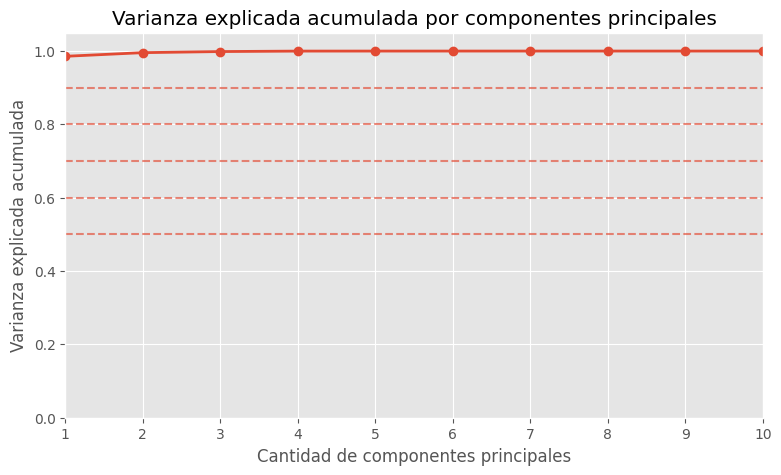

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    tabla_varianza["PC"],
    tabla_varianza["Varianza acumulada"],
    marker="o",
    linewidth=2,
)

for threshold in THRESHOLDS:
    ax.axhline(threshold, linestyle="--", alpha=0.65)

ax.set_title("Varianza explicada acumulada por componentes principales")
ax.set_xlabel("Cantidad de componentes principales")
ax.set_ylabel("Varianza explicada acumulada")
ax.set_ylim(0, 1.05)
ax.set_xlim(1, 10)
plt.show()

In [13]:
componentes_por_umbral = []

for threshold in THRESHOLDS:
    n_componentes = int(np.argmax(varianza_acumulada >= threshold) + 1)
    acumulada_real = varianza_acumulada[n_componentes - 1]
    componentes_por_umbral.append({
        "Criterio": f"{threshold:.0%}",
        "Varianza acumulada alcanzada": acumulada_real,
        "Cantidad de PC": n_componentes,
    })

tabla_componentes = pd.DataFrame(componentes_por_umbral)
tabla_componentes

,Criterio,Varianza acumulada alcanzada,Cantidad de PC
0,50%,0.985692,1
1,60%,0.985692,1
2,70%,0.985692,1
3,80%,0.985692,1
4,90%,0.985692,1


## 9. Regresion lineal con reduccion de variables mediante PCA

In [14]:
resultados = [{
    "Porcentaje de varianza explicada acumulada": "Sin PCA",
    "cantidad de PC": X_train_scaled.shape[1],
    "RMSE_entrenamiento": rmse_train_sin_pca,
    "RMSE_pruebas": rmse_test_sin_pca,
}]

for threshold in THRESHOLDS:
    n_componentes = int(np.argmax(varianza_acumulada >= threshold) + 1)
    acumulada_real = varianza_acumulada[n_componentes - 1]

    modelo_pcr = make_pipeline(
        PCA(n_components=n_componentes),
        LinearRegression(),
    )
    modelo_pcr.fit(X_train_scaled, y_train)

    pred_train_pcr = modelo_pcr.predict(X_train_scaled)
    pred_test_pcr = modelo_pcr.predict(X_test_scaled)

    resultados.append({
        "Porcentaje de varianza explicada acumulada": f"{threshold:.0%} (alcanzado: {acumulada_real:.2%})",
        "cantidad de PC": n_componentes,
        "RMSE_entrenamiento": calcular_rmse(y_train, pred_train_pcr),
        "RMSE_pruebas": calcular_rmse(y_test, pred_test_pcr),
    })

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados["RMSE_entrenamiento"] = tabla_resultados["RMSE_entrenamiento"].round(4)
tabla_resultados["RMSE_pruebas"] = tabla_resultados["RMSE_pruebas"].round(4)

tabla_resultados

,Porcentaje de varianza explicada acumulada,cantidad de PC,RMSE_entrenamiento,RMSE_pruebas
0,Sin PCA,100,0.6986,4.0494
1,50% (alcanzado: 98.57%),1,11.9169,10.2542
2,60% (alcanzado: 98.57%),1,11.9169,10.2542
3,70% (alcanzado: 98.57%),1,11.9169,10.2542
4,80% (alcanzado: 98.57%),1,11.9169,10.2542
5,90% (alcanzado: 98.57%),1,11.9169,10.2542


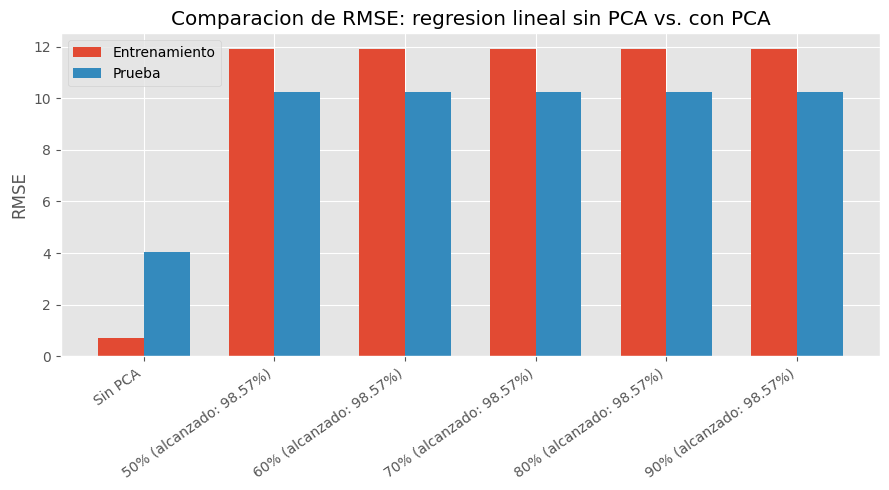

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

posiciones = np.arange(len(tabla_resultados))
ancho = 0.35

ax.bar(
    posiciones - ancho / 2,
    tabla_resultados["RMSE_entrenamiento"],
    width=ancho,
    label="Entrenamiento",
)
ax.bar(
    posiciones + ancho / 2,
    tabla_resultados["RMSE_pruebas"],
    width=ancho,
    label="Prueba",
)

ax.set_xticks(posiciones)
ax.set_xticklabels(tabla_resultados["Porcentaje de varianza explicada acumulada"], rotation=35, ha="right")
ax.set_ylabel("RMSE")
ax.set_title("Comparacion de RMSE: regresion lineal sin PCA vs. con PCA")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Conclusiones

- La base `meatspec.csv` contiene 215 observaciones, 100 variables predictoras espectrales y la variable objetivo `fat`. No se encontraron valores faltantes, por lo que la preparacion principal consistio en separar `X` e `y`, dividir los datos y normalizar las variables predictoras.
- La regresion lineal sin PCA obtuvo un RMSE de entrenamiento de aproximadamente 0.6986 y un RMSE de prueba de aproximadamente 4.0494. La diferencia entre ambos errores indica que el modelo ajusta muy bien los datos de entrenamiento, pero pierde precision al generalizar.
- En el analisis PCA, el primer componente principal explico aproximadamente 98.57% de la varianza acumulada. Por esa razon, todos los criterios solicitados, desde 50% hasta 90%, seleccionaron solamente 1 componente principal.
- La regresion lineal usando 1 componente principal obtuvo un RMSE de entrenamiento de aproximadamente 11.9169 y un RMSE de prueba de aproximadamente 10.2542. Aunque este componente resume casi toda la variabilidad de las variables predictoras, no conserva suficiente informacion util para predecir `fat` con precision.
- En esta particion de datos, el mejor desempeno predictivo corresponde a la regresion lineal sin PCA, porque presenta el menor RMSE en el conjunto de prueba. PCA reduce fuertemente la dimensionalidad, pero la varianza explicada no necesariamente equivale a capacidad predictiva sobre la variable objetivo.